### YOLO Training – Table Detection

##### Confirm GPU is detected:

In [1]:
from ultralytics import YOLO
import torch

print("GPU available:", torch.cuda.is_available())
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU available: True
CUDA device name: NVIDIA RTX 2000 Ada Generation Laptop GPU


##### Train YOLOv8

In [ ]:
from ultralytics import YOLO

# Load model (pretrained weights)
model = YOLO("yolov8s.pt")

# Train
model.train(
    data="../data/dataset.yaml",    # dataset config
    epochs=50,                       # adjust depending on dataset size
    imgsz=640,                      # YOLO image size (resize)
    batch=16,                       # adjust according to GPU memory
    device=0,                       # 0 = first GPU, 'cpu' for CPU
    project="../runs/train",        # output folder
    name="table_detection",
    exist_ok=True,                   # overwrite if same name
    patience=10,                    # Early stopping patience (epochs with no improvement)
    save_period=1                   # Save weights every epoch
)

print("Completed !")

New https://pypi.org/project/ultralytics/8.4.14 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.235  Python-3.11.0 torch-2.7.1+cu118 CUDA:0 (NVIDIA RTX 2000 Ada Generation Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=table_detection, nbs=

2026/02/19 16:53:34 INFO mlflow.tracking.fluent: Experiment with name '../runs/train' does not exist. Creating a new experiment.
2026/02/19 16:53:34 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2026/02/19 16:53:34 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.


MLflow: logging run_id(42765808b9b34fb4be06af8fccf063f8) to runs\mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\anass\Desktop\Fluxia\runs\train\table_detection
Starting training for 1 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        1/1      2.12G      1.101      5.024      1.322         24        640: 100% ━━━━━━━━━━━━ 1/1 2.3s/it 2.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.7it/s 0.2s
                   all          1          1     0.0514          1     0.0622     0.0274

1 epochs completed in 0.001 hours.
Optimizer stripped from C:\Users\anass\Desktop\Fluxia\runs\train\table_detection\weights\last.pt, 22.5MB
Optimizer stripped from C:\Users\anass\Desktop\Fluxia\runs\train\table_

##### Evaluate on Test Set

In [4]:
metrics = model.val(data="../data/dataset.yaml", split="test")
print(metrics)

Ultralytics 8.3.235  Python-3.11.0 torch-2.7.1+cu118 CUDA:0 (NVIDIA RTX 2000 Ada Generation Laptop GPU, 8188MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 2.21.7 ms, read: 2.60.9 MB/s, size: 49.3 KB)
val: Scanning C:\Users\anass\Desktop\Fluxia\data\processed\yolo_dataset\labels\test... 2 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2/2 68.0it/s 0.0s
val: New cache created: C:\Users\anass\Desktop\Fluxia\data\processed\yolo_dataset\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 5.5s/it 5.5s
                   all          2          2          1      0.997      0.995      0.755
Speed: 1.9ms preprocess, 53.2ms inference, 0.0ms loss, 14.5ms postprocess per image
Results saved to C:\Users\anass\Desktop\Fluxia\notebooks\runs\detect\val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultra

##### Visualize Predictions


image 1/1 c:\Users\anass\Desktop\Fluxia\notebooks\..\data\processed\yolo_dataset\images\test\free_1JCB63VLREJ0.jpg: 480x640 3 tables, 40.0ms
Speed: 4.1ms preprocess, 40.0ms inference, 4.3ms postprocess per image at shape (1, 3, 480, 640)


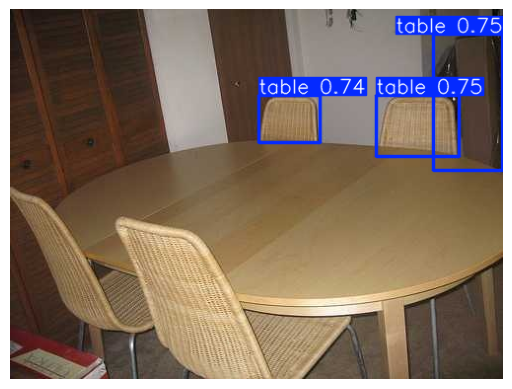

In [ ]:
results = model.predict("../data/processed/yolo_dataset/images/test/free_1JCB63VLREJ0.jpg", conf=0.5)

import cv2
import matplotlib.pyplot as plt

img = results[0].plot()
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure()
plt.imshow(img_rgb)
plt.axis('off')
plt.show()